In [68]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as pyplot
import pandas as pd
import os

# Carpetas
carpeta_rojas = "Clasificacion/ManzanaRoja"
carpeta_verdes = "Clasificacion/ManzanaVerde"

datos = []
etiquetas = []

# ==========================
# Procesar manzanas rojas
# ==========================
for archivo in os.listdir(carpeta_rojas):

    if archivo.lower().endswith(('.jpg', '.jpeg', '.png')):

        ruta = os.path.join(carpeta_rojas, archivo)

        img = Image.open(ruta)

        # Convertir a RGB por seguridad
        img = img.convert('RGB')

        # Redimensionar
        img = img.resize((100, 100))

        # Convertir a array
        vector = np.array(img).flatten()

        datos.append(vector)

        # Clase 1 = Roja
        etiquetas.append(1)

# ==========================
# Procesar manzanas verdes
# ==========================
for archivo in os.listdir(carpeta_verdes):

    if archivo.lower().endswith(('.jpg', '.jpeg', '.png')):

        ruta = os.path.join(carpeta_verdes, archivo)

        img = Image.open(ruta)

        img = img.convert('RGB')

        img = img.resize((100, 100))

        vector = np.array(img).flatten()

        datos.append(vector)

        # Clase 0 = Verde
        etiquetas.append(0)

# ==========================
# Crear DataFrame
# ==========================

X = np.array(datos)
# Normalizar a [0, 1]
X = X.astype(np.float32) / 255.0

df = pd.DataFrame(X)

df["clase"] = etiquetas

# Guardar Excel
df.to_csv("manzanas_100x100.csv", index=False)
df = pd.read_csv("manzanas_100x100.csv")

print("CSV generado correctamente")
print("Cantidad de imágenes:", len(df))
print("Número de características:", X.shape[1])

CSV generado correctamente
Cantidad de imágenes: 20
Número de características: 30000


In [69]:
df

,0,1,2,3,4,5,6,7,8,9,...,29991,29992,29993,29994,29995,29996,29997,29998,29999,clase
0,0.996078,0.996078,0.996078,0.996078,0.996078,0.996078,0.996078,0.996078,0.996078,0.996078,...,0.996078,0.996078,0.996078,0.996078,0.996078,0.996078,0.996078,0.996078,0.996078,1
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1
5,0.415686,0.003922,0.019608,0.427451,0.019608,0.011765,0.537255,0.007843,0.003922,0.670588,...,0.556863,0.011765,0.023529,0.572549,0.019608,0.035294,0.576471,0.019608,0.035294,1
6,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.992157,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1
7,0.658824,0.552941,0.439216,0.662745,0.556863,0.447059,0.666667,0.560784,0.454902,0.674510,...,0.964706,0.913725,0.819608,0.968627,0.909804,0.796078,0.972549,0.952941,0.909804,1
8,0.709804,0.729412,0.819608,0.733333,0.760784,0.843137,0.760784,0.788235,0.862745,0.780392,...,0.843137,0.850980,0.901961,0.831373,0.835294,0.894118,0.807843,0.819608,0.878431,1
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1


In [70]:
# Características (X)
X = df.drop("clase", axis=1)

# Etiquetas (y)
y = df["clase"]

In [71]:
m,n = X.shape
print("Cantidad de imágenes:", m)
print("Número de características:", n)

Cantidad de imágenes: 20
Número de características: 30000


### Separar 80% entrenamiento y 20% prueba 

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

### Concatenamos en X_train y X_test

In [73]:
X_train = np.concatenate([np.ones((X_train.shape[0], 1)), X_train],axis=1)
print(X_train.shape)

(16, 30001)


In [74]:
X_test = np.concatenate([np.ones((X_test.shape[0], 1)), X_test],axis=1)
print(X_test.shape)

(4, 30001)


In [75]:
m,n =X_train.shape

### Funcion de la Sigmoide

In [76]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

## **Definicion de Funcion de Costo**

In [77]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))

    # Clip h to avoid log(0) or log(1-1)
    epsilon = 1e-10
    h = np.clip(h, epsilon, 1 - epsilon)

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

## **Definicion del Desenso Por el Gradiente**

In [78]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

## **Función de Predicción**

theta calculado por el descenso por el gradiente: [ 0.00598308 -0.00136276 -0.00255356 ...  0.00042343 -0.00104139
 -0.00066579]


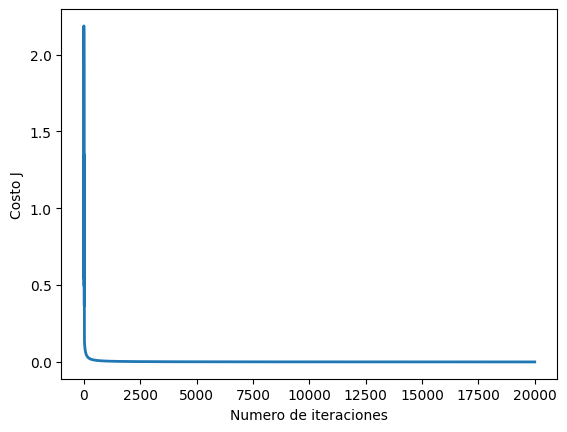

In [79]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 20000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(n)

# ejecuta descenso por el gradiente
theta, J_history = descensoGradiente(theta, X_train, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

### Predicciones con las imagenes de X_test

In [95]:
X_test.shape

(4, 30001)

In [96]:
y_test.head()

16    0
13    0
2     1
6     1
Name: clase, dtype: int64

In [97]:
for i in range(4):

    # Predicción usando el ejemplo i
    label = sigmoid(np.dot(X_test[i], theta))

    # Valor real
    real_label = y_test.iloc[i]

    # Mostrar resultados
    print(f'Predicción {i+1}')
    print(f'Label real: ${real_label:.0f}')
    print(f'Label predecido en porcentaje: {label * 100}%')
    print('-----------------------------')

Predicción 1
Label real: $0
Label predecido en porcentaje: 0.04564236731738167%
-----------------------------
Predicción 2
Label real: $0
Label predecido en porcentaje: 0.13009596502506493%
-----------------------------
Predicción 3
Label real: $1
Label predecido en porcentaje: 99.99794955071837%
-----------------------------
Predicción 4
Label real: $1
Label predecido en porcentaje: 99.95524740856231%
-----------------------------


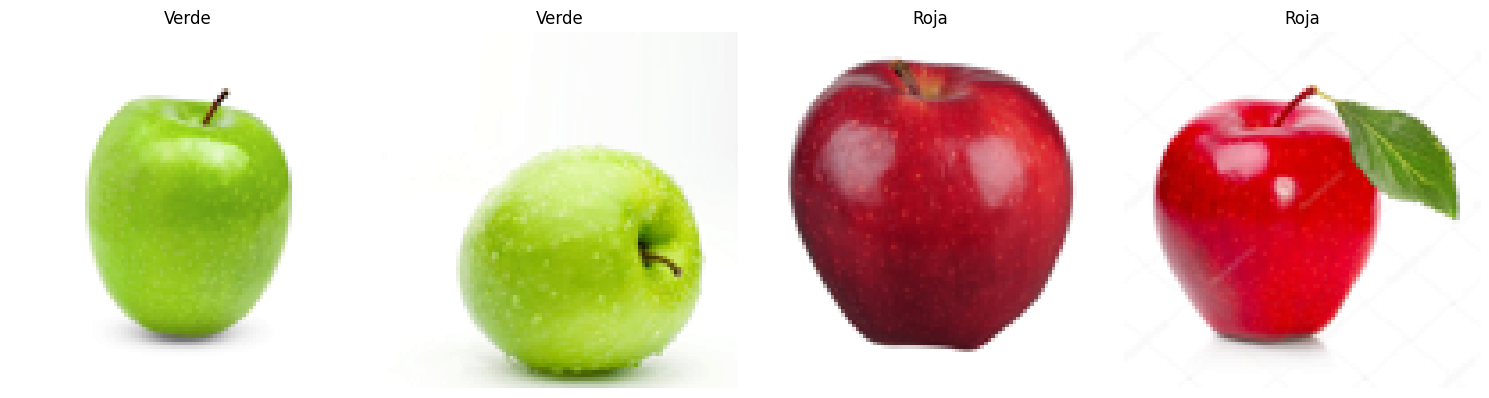

In [115]:
import matplotlib.pyplot as plt
import math

n = len(X_test)
columnas = 4
filas = math.ceil(n / columnas)

plt.figure(figsize=(15, filas * 4))

for i in range(n):

    plt.subplot(filas, columnas, i + 1)

    # Quitar bias
    imagen = X_test[i, 1:]

    # Reconstruir
    imagen = imagen.reshape(100, 100, 3)

    plt.imshow(imagen)

    if y_test.iloc[i] == 1:
        plt.title("Roja")
    else:
        plt.title("Verde")

    plt.axis("off")

plt.tight_layout()
plt.show()